<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/sentiment_analiza_std.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analiza Sentymentu z Regresją Logistyczną


**Dane:** IMDb Movie Reviews — 50 000 recenzji filmowych (etykiety: `positive` / `negative`)

> 📦 Dataset pochodzi z: `datasets` (HuggingFace) lub można pobrać z: https://ai.stanford.edu/~amaas/data/sentiment/

## 0. Importy i konfiguracja

In [ ]:
# Instalacja jeśli brakuje paczek
# !pip install datasets wordcloud nltk scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

# Sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Pobranie zasobów NLTK (tylko raz)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

# Estetyka wykresów
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = {'positive': '#27AE60', 'negative': '#E74C3C'}

print('Importy OK ✓')

Importy OK ✓


---
## 1. Wczytanie danych

In [ ]:
# Opcja A: przez HuggingFace datasets (wymaga: pip install datasets)
from datasets import load_dataset
raw = load_dataset('imdb')
train_df = pd.DataFrame(raw['train']).rename(columns={'text': 'review', 'label': 'sentiment'})
test_df  = pd.DataFrame(raw['test']).rename(columns={'text': 'review', 'label': 'sentiment'})

# Mapowanie: 0 -> negative, 1 -> positive
label_map = {0: 'negative', 1: 'positive'}
train_df['sentiment'] = train_df['sentiment'].map(label_map)
test_df['sentiment']  = test_df['sentiment'].map(label_map)

# Łączymy do jednego DataFrame na potrzeby EDA
df = pd.concat([train_df, test_df], ignore_index=True)

print(f'Łączna liczba recenzji: {len(df):,}')
print(f'Kolumny: {df.columns.tolist()}')
df.head(3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Łączna liczba recenzji: 50,000
Kolumny: ['review', 'sentiment']


,review,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",negative
2,If only to avoid making this type of film in t...,negative


In [ ]:
# Podstawowe info o zbiorze


---
## 2. Eksploracyjna Analiza Tekstu (EDA)

Zanim wytrenujemy model, musimy **zrozumieć dane**. EDA dla tekstu obejmuje:
- rozkład klas (balance)
- długość recenzji
- najczęstsze słowa
- chmury słów
- charakterystyczne słowa per klasa

In [ ]:
#-- 2.1 Rokzład klas--#

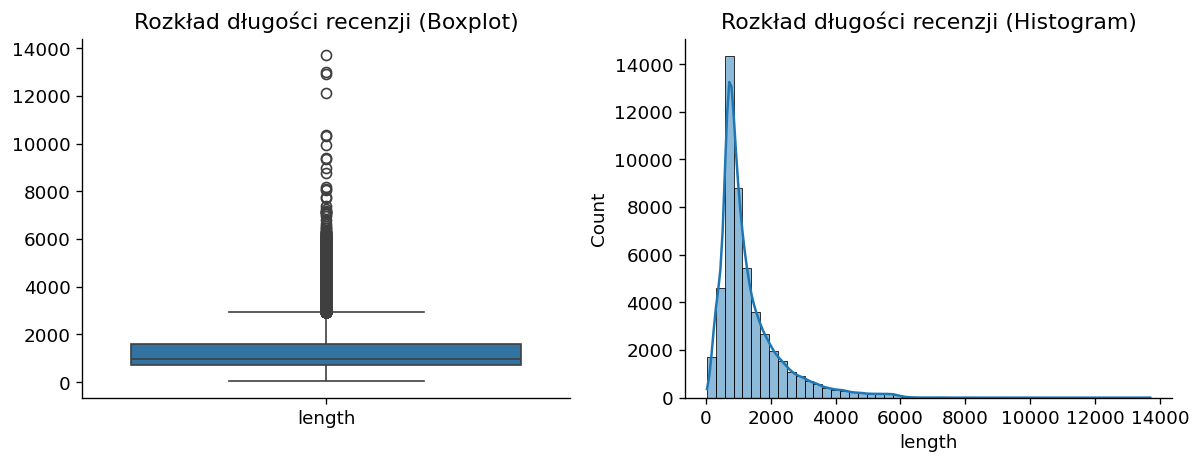

In [ ]:
# --- 2.2 Długość recenzji ---j
boxplot_df = pd.DataFrame({'length': df['review'].apply(len)})
hist_df = pd.DataFrame({'length': df['review'].apply(len)})

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=boxplot_df, ax=axs[0])
sns.histplot(data=hist_df, x='length', bins=50, kde=True, ax=axs[1])
axs[0].set_title('Rozkład długości recenzji (Boxplot)')
axs[1].set_title('Rozkład długości recenzji (Histogram)')
plt.tight_layout()
plt.show()

In [ ]:
# --- 2.3 Najczęstsze słowa (przed czyszczeniem) ---
def top_words(texts, n=20):
    """Zwraca n najczęstszych słów z listy tekstów."""
    pass


In [ ]:
# --- 2.4 Chmura słów (przed czyszczeniem) ---


---
## 3. Czyszczenie danych (Preprocessing)

Typowy pipeline dla tekstu:
1. **Lowercase** — ujednolicenie wielkości liter
2. **Usunięcie HTML** — recenzje z internetu zawierają tagi
3. **Usunięcie znaków specjalnych i cyfr**
4. **Tokenizacja**
5. **Stop words** — usunięcie słów nieznaczących (the, a, is...)
6. **Lematyzacja** — sprowadzenie do formy podstawowej (running → run)

> **Ważne:** preprocessing to decyzja projektowa — każdy krok może pomóc lub zaszkodzić. Np. przy negacji *'not good'* usunięcie *'not'* jako stop word niszczy informację o negacji.

In [ ]:
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str, remove_stopwords: bool = True) -> str:
    """Pełny pipeline czyszczenia tekstu."""
    pass
    # 1. Lowercase

    # 2. Usunięcie tagów HTML

    # 3. Usunięcie URL

    # 4. Usunięcie znaków specjalnych (zostają spacje i litery)

    # 5. Usunięcie wielokrotnych spacji

    # 6. Tokenizacja i opcjonalne usunięcie stop words

    # 7. Lematyzacja


# Test na przykładzie
przyklad = "This film was <b>absolutely TERRIBLE</b>! I don't know why people love it... 3/10 would NOT recommend."
print('Oryginał:')
print(przyklad)
print('\nPo czyszczeniu:')
print(clean_text(przyklad))

Oryginał:
This film was <b>absolutely TERRIBLE</b>! I don't know why people love it... 3/10 would NOT recommend.

Po czyszczeniu:
film absolutely terrible know people love would recommend


In [ ]:
# Zastosowanie na całym zbiorze
print('Czyszczenie danych... (może potrwać 1-2 min)')


Czyszczenie danych... (może potrwać 1-2 min)


In [ ]:
# --- Najczęstsze słowa PO czyszczeniu ---


In [ ]:
# --- Chmury słów PO czyszczeniu ---


In [ ]:
# --- Słowa różnicujące: TF względny pozytywnych vs negatywnych ---
from sklearn.feature_extraction.text import TfidfVectorizer

# Liczymy częstość per klasa (normalizowana)
def word_freq_per_class(df, col='review_clean', n=15):
    pass

# freq = word_freq_per_class(df)



---
## 4. Podział na zbiór treningowy i testowy

### Dlaczego dzielimy dane?

**Generalizacja** — celem modelu ML nie jest zapamiętanie danych treningowych, lecz nauczenie się ogólnych wzorców, które działają na nowych, niewidzianych danych.

**Overfitting (przeuczenie)** — model, który trenuje zbyt długo lub ma zbyt dużo parametrów, może "nauczyć się na pamięć" dane treningowe. Taki model ma wysoką dokładność na zbiorze treningowym, ale niską na testowym.

```
Cały zbiór
├── Train (70-80%): model uczy się wag
├── Dev/Validation (opcjonalnie): dobór hiperparametrów
└── Test (20-30%): ostateczna ocena — UŻYWAMY TYLKO RAZ!
```

> ⚠️ **Kluczowa zasada:** zbioru testowego **nie wolno oglądać** przed zakończeniem treningu. Każde spojrzenie na wyniki testowe i modyfikacja modelu na tej podstawie to *data leakage*.

---
## 5. Wektoryzacja i Trenowanie Modelu

### Od tekstu do wektora

Regresja logistyczna wymaga numerycznych cech. Używamy `CountVectorizer` (BoW):

$$x_j = \text{count}(\text{słowo}_j \in \text{recenzja})$$

### Cross-entropy jako funkcja straty

$$L(y, \hat{y}) = -\left[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})\right]$$

### SGD — reguła aktualizacji wag

$$w_j \leftarrow w_j - \eta \cdot \underbrace{(\hat{y} - y)}_{\text{błąd}} \cdot \underbrace{x_j}_{\text{cecha}}$$

gdzie $\eta$ to **learning rate** (hiperparametr).

W sklearn: `SGDClassifier(loss='log_loss')` implementuje dokładnie ten algorytm.

In [ ]:
# Pipeline: wektoryzacja + model
# Używamy Pipeline — zapobiega data leakage (fit tylko na train!)



---
## 6. Ewaluacja Modelu

### Metryki klasyfikacji binarnej

| Metryka | Wzór | Co mierzy |
|---------|------|-----------|
| **Precision** | TP / (TP + FP) | Ze wszystkich wskazanych jako `+`, ile faktycznie jest `+`? |
| **Recall** | TP / (TP + FN) | Ze wszystkich faktycznych `+`, ile model wykrył? |
| **F1** | 2·P·R / (P+R) | Harmoniczna średnia P i R |
| Accuracy | (TP+TN) / all | Odsetek poprawnych — **myląca przy niezbalansowanych danych!** |

In [ ]:
def evaluate_model(pipeline, X_test, y_test, model_name='Model'):
    """Kompleksowa ewaluacja modelu."""
    pass

# results_bow = evaluate_model(pipeline_bow, X_test, y_test, 'BoW + SGD (unigramy)')

---
## 7. Interpretacja Wag Cech

Regresja logistyczna jest **interpretowalnym modelem** — wagi bezpośrednio mówią nam, które słowa model uznał za ważne.

- **Waga dodatnia** → słowo przesuwa decyzję w kierunku klasy `positive`
- **Waga ujemna** → słowo przesuwa decyzję w kierunku klasy `negative`
- **|waga|** → siła wpływu

---
## 8. Unigramy vs Bigramy (ngram_range=(1,2))

**Problem negacji z unigramami:**
```
"not good" → ['not', 'good']  
# 'good' dostaje wagę pozytywną — błąd!

"not good" → ['not', 'good', 'not good']  
# 'not good' jako bigram dostaje wagę ujemną — poprawnie!
```

Używając `ngram_range=(1,2)` tworzymy jednocześnie unigramy i bigramy jako cechy.

---
# 🎯 Zadania do samodzielnego wykonania

Poniższe zadania realizujecie samodzielnie lub w parach. Każde zadanie zawiera **wskazówkę** — ale spróbujcie najpierw bez niej.

---

### ✏️ Zadanie 1 — Entropia zbioru danych

Oblicz entropię zbioru IMDb **ręcznie** (wzorem Shannona):

$$H(p) = -\sum_{k} p_k \cdot \log_2(p_k)$$

1. Oblicz $H$ dla całego zbioru.
2. Czy zbiór jest zbalansowany? Co by znaczyło $H = 0$, a co $H = 1$?
3. Oblicz $H$ dla hipotetycznego zbioru gdzie 90% to klasa `positive`. Co to oznacza dla modelu?

<details><summary>💡 Wskazówka</summary>

```python
probs = y.value_counts(normalize=True).values
H = -np.sum(probs * np.log2(probs))
```
</details>

In [ ]:
# ZADANIE 1 — Twój kod tutaj



### ✏️ Zadanie 2 — Wpływ learning rate na trening

Wytrenuj 3 modele SGD z różnymi wartościami `eta0` (learning rate):
- `eta0 = 0.001`
- `eta0 = 0.1`  
- `eta0 = 10.0`

Pamiętaj: musisz ustawić `learning_rate='constant'` żeby eta0 się nie zmieniało.

Porównaj F1 na zbiorze testowym. Który model działa najlepiej? Dlaczego zbyt duże eta może zaszkodzić?

<details><summary>💡 Wskazówka</summary>

```python
for eta in [0.001, 0.1, 10.0]:
    clf = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=eta, ...)
    # ...
```
</details>

In [ ]:
# ZADANIE 2 — Twój kod tutaj



### ✏️ Zadanie 3 — Analiza błędów modelu

Znajdź **false negatives** (recenzje pozytywne, które model sklasyfikował jako negatywne) i **false positives** (recenzje negatywne sklasyfikowane jako pozytywne).

1. Wypisz 5 przykładów FN i 5 FP (oryginalne recenzje, przed czyszczeniem).
2. Czy widzisz wspólny wzorzec? Np. sarkasm, negacja, żargon filmowy?
3. Zaproponuj jedno ulepszenie preprocessingu, które mogłoby naprawić niektóre z tych błędów.

<details><summary>💡 Wskazówka</summary>

```python
y_pred = pipeline_bow.predict(X_test)
errors = pd.DataFrame({'review': X_test.values, 'true': y_test.values,
                        'pred': y_pred, 'orig': df.loc[X_test.index, 'review'].values})
false_neg = errors[(errors['true']=='positive') & (errors['pred']=='negative')]
```
</details>

In [ ]:
# ZADANIE 3 — Twój kod tutaj



### ✏️ Zadanie 4 — Regularyzacja L1 vs L2

Regresja logistyczna z regularyzacją L1 tworzy **rzadkie modele** (wiele wag = 0). L2 preferuje małe, ale niezerowe wagi.

Wytrenuj dwa modele: z `penalty='l1'` i `penalty='l2'`.

1. Ile cech ma niezerową wagę w każdym modelu? (`np.sum(coef != 0)`)
2. Porównaj F1. Który model jest lepszy?
3. Jak interpretujesz różnicę w liczbie aktywnych cech?

> Uwaga: SGDClassifier z `penalty='l1'` wymaga `max_iter` większego lub solvera `liblinear` w `LogisticRegression`.

<details><summary>💡 Wskazówka</summary>

```python
# Alternatywnie użyj LogisticRegression
from sklearn.linear_model import LogisticRegression
clf_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0)
clf_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=1.0)
```
</details>

In [ ]:
# ZADANIE 4 — Twój kod tutaj



### ✏️ Zadanie 5 — TF-IDF zamiast BoW

Zamień `CountVectorizer` na `TfidfVectorizer` w pipeline (zachowując `ngram_range=(1,1)`).

1. Wytrenuj i oceń model. Czy F1 jest lepsze niż z BoW?
2. Wypisz top 20 słów z największą wagą TF-IDF dla każdej klasy.
3. Czy słowa charakterystyczne różnią się od tych w modelu BoW?

<details><summary>💡 Wskazówka</summary>

```python
pipeline_tfidf = Pipeline([
    ('vect', TfidfVectorizer(ngram_range=(1,1), min_df=5, max_features=50_000)),
    ('clf', SGDClassifier(loss='log_loss', ...))
])
```
</details>

In [ ]:
# ZADANIE 5 — Twój kod tutaj



### ✏️ Zadanie 6 (★ dodatkowe) — Własny recenzor filmowy

Napisz funkcję `predict_sentiment(text, pipeline)` która:
1. Czyści tekst (wywołując `clean_text`)
2. Zwraca: etykietę klasy, prawdopodobieństwo pozytywnego, 5 słów o największym wpływie na decyzję

Przetestuj na 3 recenzjach, które sam piszesz (po angielsku).

<details><summary>💡 Wskazówka</summary>

```python
def predict_sentiment(text, pipeline):
    clean = clean_text(text)
    label = pipeline.predict([clean])[0]
    proba = pipeline.predict_proba([clean])[0]
    # Możesz też zajrzeć w wagi słów z tekstu:
    # vect = pipeline.named_steps['vect']
    # coef = pipeline.named_steps['clf'].coef_[0]
    # ...
    return label, proba, top_features
```
</details>

In [ ]:
# ZADANIE 6 — Twój kod tutaj



---
## Podsumowanie

| Pojęcie | Co to jest | Gdzie w kodzie |
|---------|-----------|----------------|
| **BoW** | Tekst → wektor zliczeń słów | `CountVectorizer` |
| **Cross-entropy** | Funkcja straty: $L = -[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ | `loss='log_loss'` w SGDClassifier |
| **SGD** | Iteracyjna aktualizacja wag: $w \leftarrow w - \eta(\hat{y}-y)x$ | `SGDClassifier` |
| **Regularyzacja L2** | Penalizuje duże wagi, zapobiega overfittingowi | `penalty='l2'` |
| **Bigramy** | Pary sąsiednich słów jako cechy, częściowo naprawiają negację | `ngram_range=(1,2)` |
| **Precision/Recall/F1** | Metryki lepsze niż accuracy przy niezbalansowanych danych | `classification_report` |
| **Entropia** | Miara niepewności rozkładu, $H = -\sum p \log_2 p$ | Ręczne obliczenie |


---
*Blok 8 · NLP/ML · Jurafsky & Martin, rozdz. 4*